In [23]:
from pathlib import Path
import numpy as np

def load_scanned_object(name):
    E_shift = 2
    if name == "pigment_palette":
        e_xy = np.load(Path("data/objects/pigment_palette/GEM_Cr_PBS1_PadsPalette_ArCO2_80_20_Gain_35_Thr_35_HV3490_Xray_50kV_1mA_Pinhol_2mm_sum_3-23_GainCorr_Fe.npz"), allow_pickle=True)["E_xy"].astype(float) / (1 << E_shift)

        e_xy= np.fliplr(np.rot90(e_xy, k=1))
        peaks = None
        peak_energies = None
    else:
        raise ValueError(f"Unknown object name: {name}")

    return e_xy, peaks, peak_energies

pad_names = [
    "mn_fe",          # Umbra
    "ca_zn",          # Żółta neapolitańska ???
    "s_as_ca_zn",     # Aurypigment
    "ca_zn_pb",       # Żółta neapolitańska ???
    "mn",             # Fiolet manganowy
    
    "s_hg",           # Umbra
    "wood",           # Deska (Drewno)
    "cr",             # Zieleń chromowa
    "ti",             # Biel tytanowa
    "s_as",           # Realgar (Madryt)

    "si_zr",          # Ceruleum
    "fe",             # Raw Siena
    "na_al_si_s",     # Ultramaryna
    "s_k_cd",         # Żółta kadmowa
    "si_k_co",        # Smalta

    "sn_pb",          # Żółta cynowo-ołowiowa
    "cu",             # Malachit
    "pb",             # Minia ołowiowa
    "ag",             # Srebro
    "al",             # Aluminium

    "s_zn",           # Biel cynkowa
    "co",             # Niebieski kobaltowy
    "s_ba",           # Biel barytowa
    "s_au",           # Złoto
    "cu_zn"           # Mosiądz
]

def filtered_element_name(pad_name, excluded_elements):
    return "_".join([name for name in pad_name.split("_") if name not in excluded_elements])

def generate_bounding_boxes(pads):
    grid_size = (5, 5)
    box_size = (16, 16)
    offset = (9, 9)
    spacing = (6, 6)

    positions = {}
    rows, cols = grid_size
    box_h, box_w = box_size
    x_offset, y_offset = offset
    x_spacing, y_spacing = spacing

    count = 1
    for i in range(rows):
        for j in range(cols):
            x1 = x_offset + i * (box_h + x_spacing)
            x2 = x1 + box_h
            y1 = y_offset + j * (box_w + y_spacing)
            y2 = y1 + box_w
            positions[pads[i*cols + j]] = (x1, x2, y1, y2)
            count += 1
    
    return positions

excluded_elements = {"al", "ag", "s", "si", "na"}
pad_names = [filtered_element_name(name, excluded_elements) for name in pad_names ]
pad_positions = generate_bounding_boxes(pad_names)

def average_patches(e_xy, patch_size = 1):
    if patch_size == 1:
        return e_xy
    A = patch_size
    X, Y, C = e_xy.shape

    X_trim = X - (X % A)
    Y_trim = Y - (Y % A)
    e_xy = e_xy[:X_trim, :Y_trim, :]

    X_prime = X_trim // A
    Y_prime = Y_trim // A
    e_xy_patched = e_xy.reshape(X_prime, A, Y_prime, A, C)
    averaged = e_xy_patched.mean(axis=(1, 3))

    return averaged  # shape will be (X//A, Y//A, C)

In [24]:
object_name = "pigment_palette"
patch_size = 1 

e_xy, peaks, peak_energies = load_scanned_object(object_name)
# e_xy = average_patches(e_xy, patch_size)

In [25]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

def apply_smoothing_and_padding(e_xy, padding_size=196, spatial_padding=False):
    result = e_xy
    if spatial_padding:
        result = gaussian(result, sigma=0.6)
    result = np.apply_along_axis(
        gaussian, axis=2, arr=result, sigma=64, preserve_range=True
    )
    
    result[:, :, :padding_size] = 0
    result[:, :, -padding_size:] = 0
    
    max_norm_coeff = np.max(result, axis=2, keepdims=True)
    result /= max_norm_coeff

    return result 

# e_xy_smooth = apply_smoothing_and_padding(e_xy, spatial_padding=True)

/tmp/ipykernel_32328/665309315.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


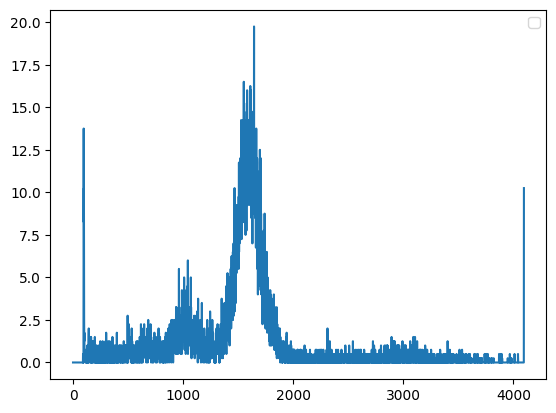

In [26]:
import matplotlib.pyplot as plt
import random 
aa = np.copy(e_xy[20, 40])
plt.plot(e_xy[20, 40])
plt.legend()

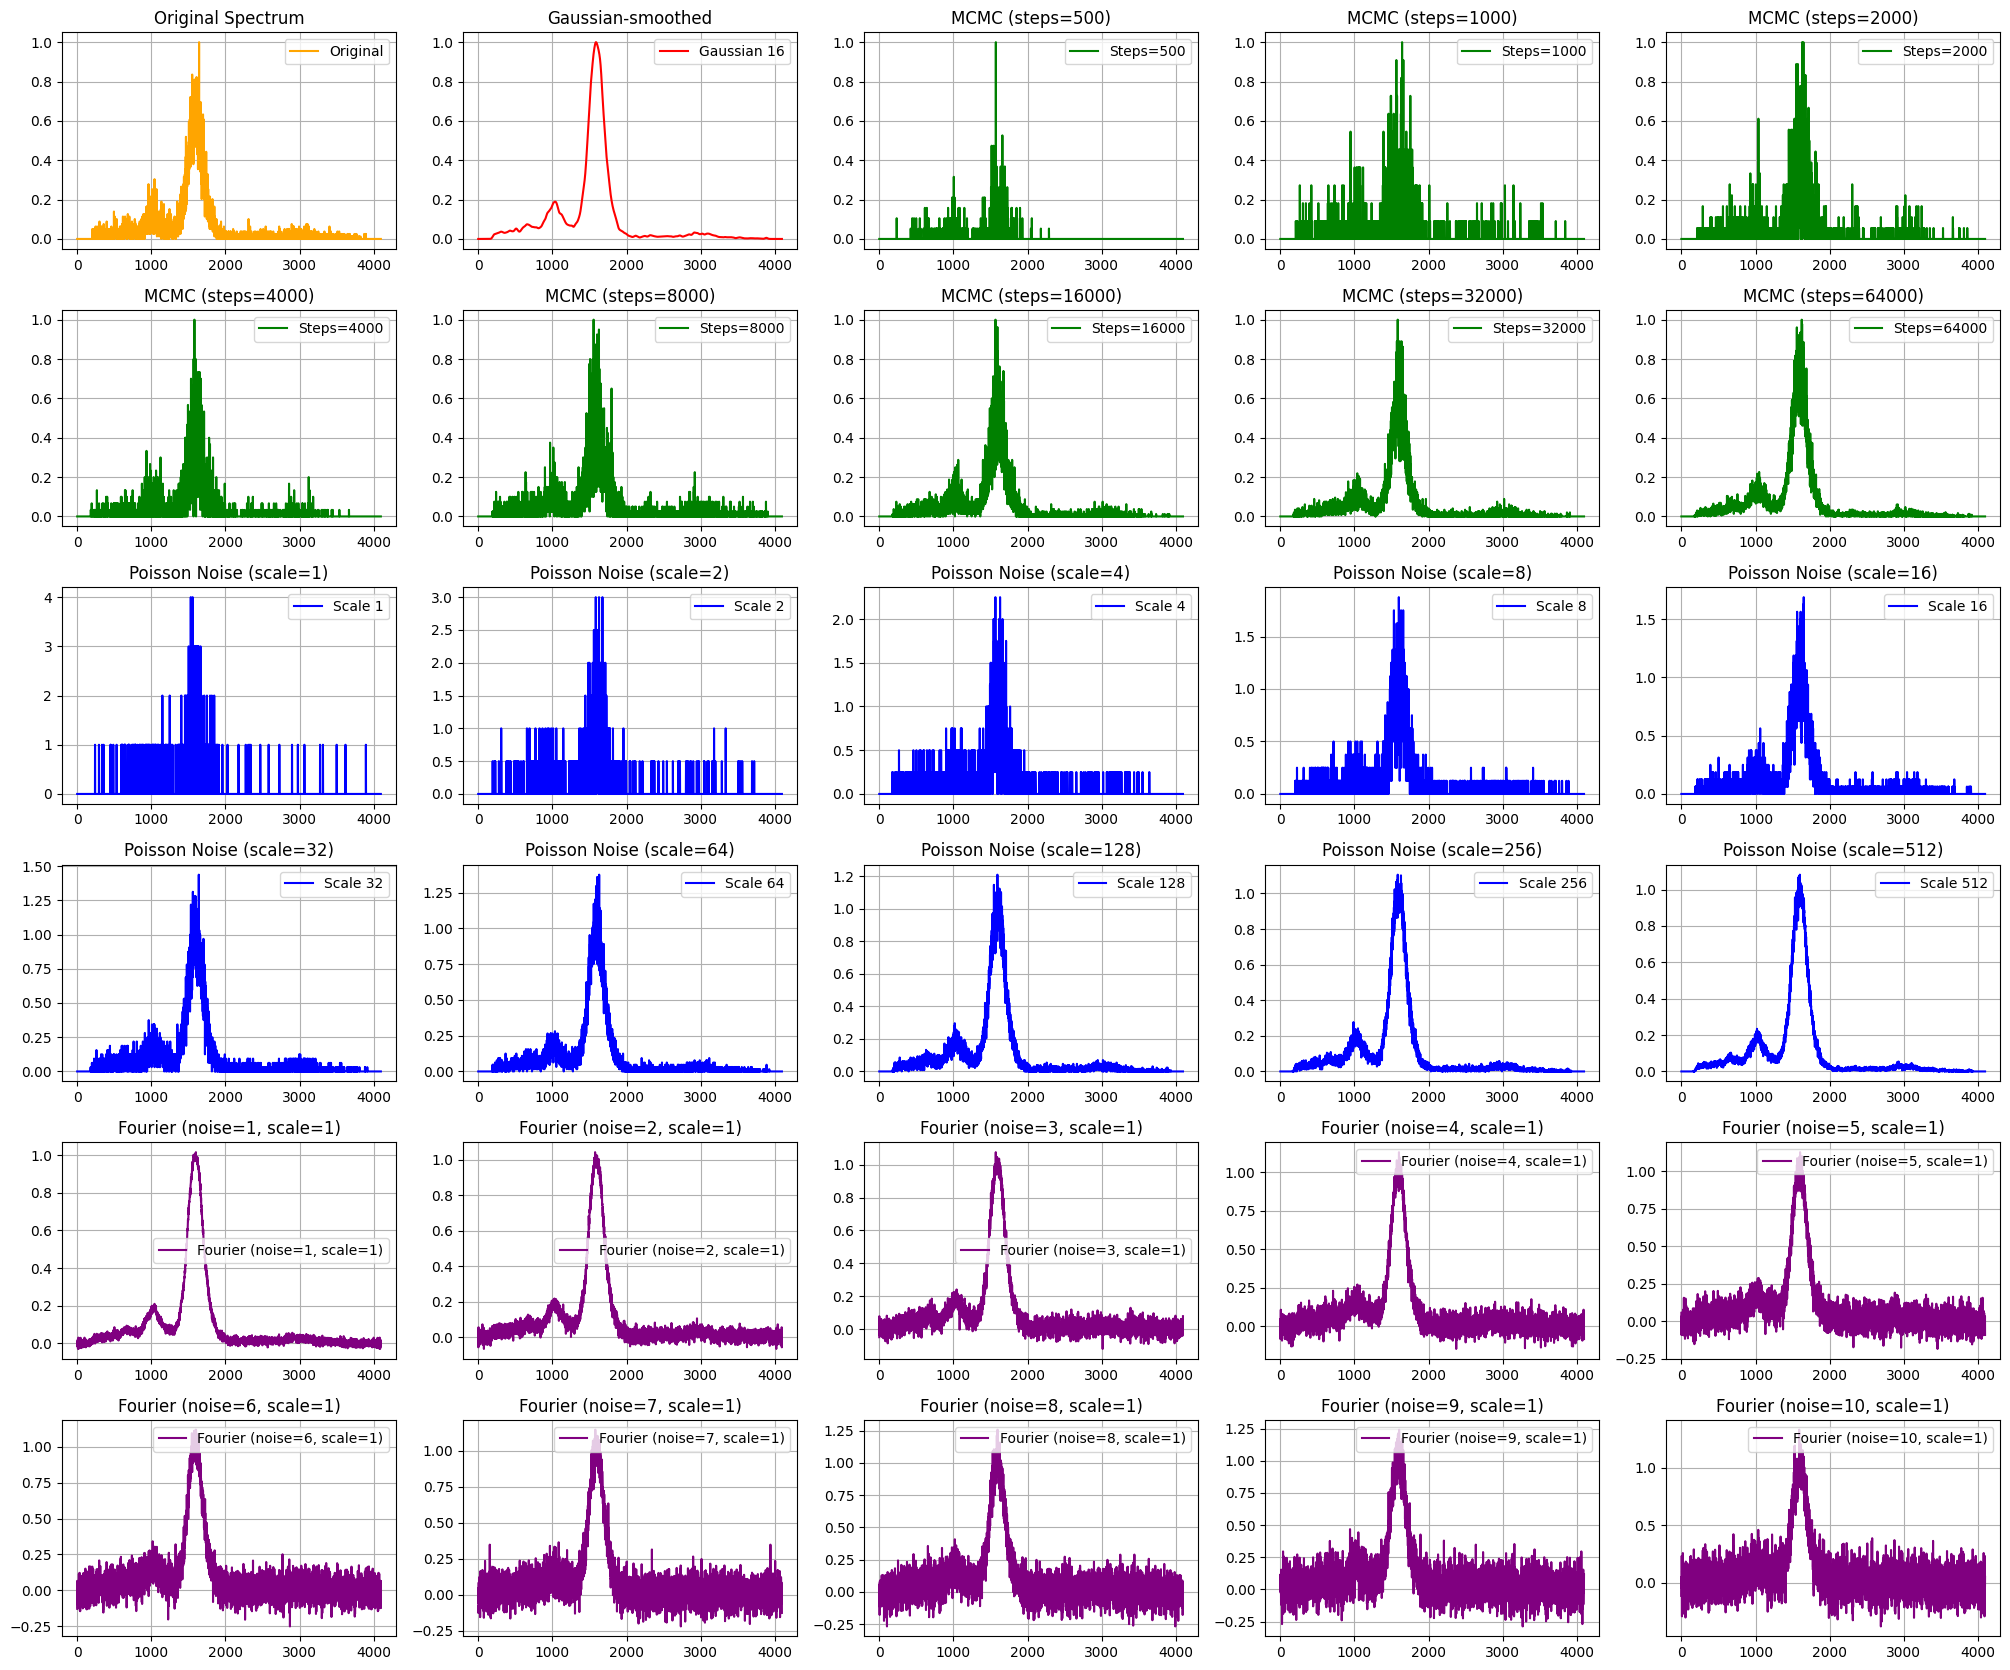

In [34]:
from src.FeatureEnhancer import FeatureEnhancer
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter as gaussian
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

""" set a random generator to have the same output each time, comment
    to generate a new set each time
"""
#np.random.seed(0)

""" fairly complicated signal - ours is more complicated... """
time = np.linspace(0, 10, 500)
original_series = np.sin(2 * np.pi * 0.5 * time) + 0.2 * np.random.normal(size=time.shape)

""" this is the engine for augmentation, change the noise and scale """
def fourier_augment(time_series, noise_factor=0.1, scale_factor=1.2):
    freq_domain = np.fft.fft(time_series)
    augmented_freq_domain = freq_domain * scale_factor
    noise = np.random.normal(size=freq_domain.shape) * noise_factor
    augmented_freq_domain = augmented_freq_domain + noise
    augmented_time_series = np.fft.ifft(augmented_freq_domain).real
    return augmented_time_series

def fourier_augment_dc(time_series, noise_factor=0.1, scale_factor=1.2):
    """
    another function preserving DC component of the signal

    Parameters:
    - time_series: The input time series data (1D array).
    - noise_factor: Magnitude of random noise added to the frequency components.
    - scale_factor: Multiplicative factor for scaling the frequency components.
    """
    # Perform Fourier Transform to convert to frequency domain
    freq_domain = np.fft.fft(time_series)

    # Preserve the DC component
    dc_component = freq_domain[0]

    # Apply scaling and noise to non-DC components
    freq_domain *= scale_factor
    freq_domain += np.random.normal(size=freq_domain.shape) * noise_factor

    # Restore the DC component
    freq_domain[0] = dc_component

    # Perform inverse Fourier Transform to convert back to time domain
    augmented_time_series = np.fft.ifft(freq_domain).real
    return augmented_time_series


# """ multiple augmented series """
# augmented_series_list = [fourier_augment_dc(original_series, noise_factor=0.05, scale_factor=1.05) for _ in range(10)]

# Zero out edge values
e_xy[:, :, :200] = 0
e_xy[:, :, -200:] = 0

# Select and normalize a single spectrum
A = e_xy[20, 40].copy()
A /= np.max(A)

# Apply Gaussian smoothing
B = gaussian(A, sigma=16)
B /= np.max(B)

# MCMC steps
steps_list = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]

# Function to add Poisson noise
def add_poisson_noise(signal, scale=1000):
    # signal = np.clip(signal, 0, None)  # ensure non-negative
    noisy = np.random.poisson(signal * scale) / scale
    return noisy

# Total number of plots: Original + Smoothed + MCMC + Poisson
n_poisson = 10
n_mcmc = len(steps_list)
n_fourier = 10
n_total = 2 + n_mcmc + n_poisson + n_fourier

# Subplot setup
cols = 5
rows = (n_total + cols - 1) // cols
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(4 * cols, 2.8 * rows))
axes = axes.flatten()

# Plot Original
axes[0].plot(A, label="Original", color='orange')
axes[0].set_title("Original Spectrum")
axes[0].legend()
axes[0].grid(True)

# Plot Gaussian-smoothed
axes[1].plot(B, label="Gaussian 16", color='red')
axes[1].set_title("Gaussian-smoothed")
axes[1].legend()
axes[1].grid(True)

# Plot MCMC-enhanced spectra
for i, steps in enumerate(steps_list, start=2):
    C = FeatureEnhancer._metropolis_hasting_mcmc(B, steps=steps)
    C /= np.max(C)
    axes[i].plot(C, label=f"Steps={steps}", color="green")
    axes[i].set_title(f"MCMC (steps={steps})")
    axes[i].legend()
    axes[i].grid(True)

# Plot Poisson-noised versions
start_index = 2 + n_mcmc
for j in range(n_poisson):
    scale = 2 ** j
    noisy = add_poisson_noise(B, scale=scale)
    idx = start_index + j
    axes[idx].plot(noisy, label=f"Scale {scale}", color="blue")
    axes[idx].set_title(f"Poisson Noise (scale={scale})")
    axes[idx].legend()
    axes[idx].grid(True)


start_index = idx + 1
for k in range(n_fourier):
    noise_factor = 1 + k * 1 
    scale_factor = 1 #+ k * 0.5
    fourier_augmented = fourier_augment(B, noise_factor=noise_factor, scale_factor=scale_factor)

    idx = start_index + k
    axes[idx].plot(fourier_augmented, label=f"Fourier (noise={noise_factor}, scale={scale_factor})", color="purple")
    axes[idx].set_title(f"Fourier (noise={noise_factor}, scale={scale_factor})")
    axes[idx].legend()
    axes[idx].grid(True)




# Hide any unused axes
for k in range(n_total, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.savefig("noise_augmentation_comparison.png")
    

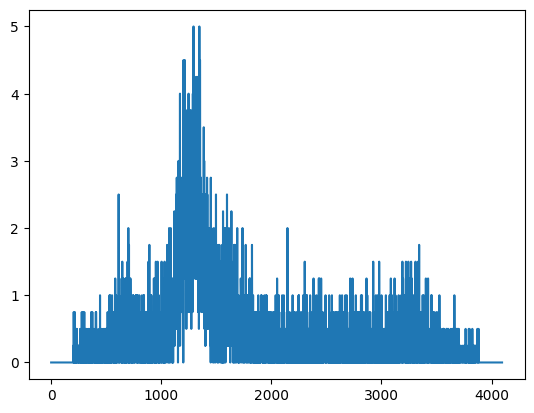

In [24]:
plt.plot(e_xy[20, 20])

In [25]:
from tqdm import tqdm
if object_name == "pigment_palette":
    e_xy_processed = e_xy 
    for pad_name, (x1, x2, y1, y2) in tqdm(pad_positions.items()):
        # plt.figure(random.randint(1, int(10e10)))
        if pad_name in ["", "mn_fe", "cu_zn", "as_ca_zn", "ca_zn_pb", "sn_pb"]:
            continue
        spectra_calibrated = np.load(Path("data/objects/pigment_palette/pad_average_spectra_calibrated.npz"), allow_pickle=True)
        peaks = spectra_calibrated["peaks"].item()[pad_name]
        peak_energies = spectra_calibrated["energies"].item()[pad_name]
        energy_range, temp = DataPreprocessor.processed_spectra(e_xy[x1:x2, y1:y2], peaks, peak_energies, discrete_transformation=True)
        e_xy[x1:x2, y1:y2] = temp.astype("float")

H, W, C = e_xy.shape

100%|██████████| 23/23 [00:00<00:00, 102.40it/s]


In [26]:
e_xy[:, :, :256] = 0
e_xy[:, :, -256:] = 0

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_pad_max_peak_positions(e_xy, object_name):
    peak_map = np.argmax(e_xy, axis=2)

    _, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(peak_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Max peak position")
    for pad_name, (x1, x2, y1, y2) in  pad_positions.items():
        width, height = y2 - y1, x2 - x1
        rect = patches.Rectangle((y1, x1), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    plt.title("Max Peak Positions")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    
    plt.savefig(f"data/plots/max_peak_positions{object_name}.svg", bbox_inches='tight',  pad_inches=0)

def plot_pad_photon_counts(e_xy, object_name): 
    photon_count_map = np.sum(e_xy, axis=2)
    photon_count_map /= np.max(photon_count_map)

    _, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    im = ax.imshow(photon_count_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    plt.savefig(f"data/plots/photon_counts{object_name}.svg", bbox_inches='tight',  pad_inches=0)

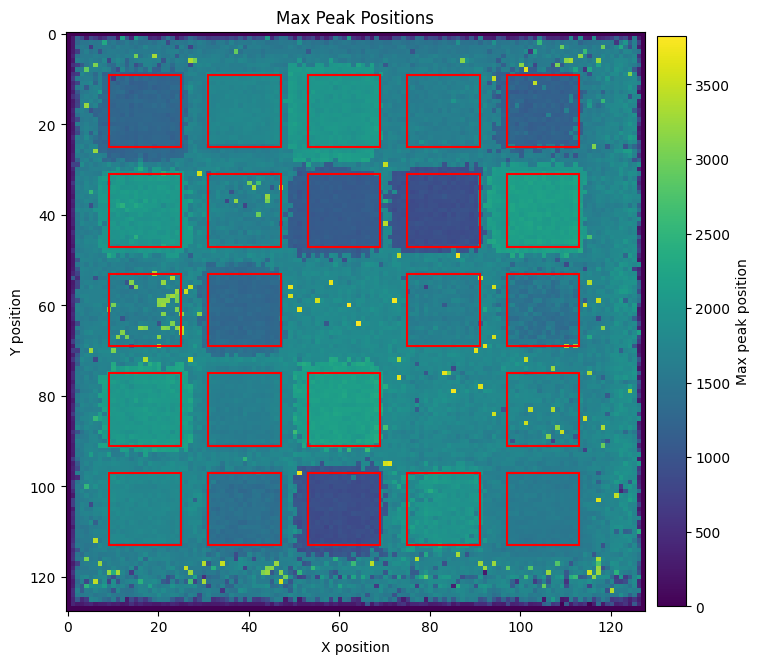

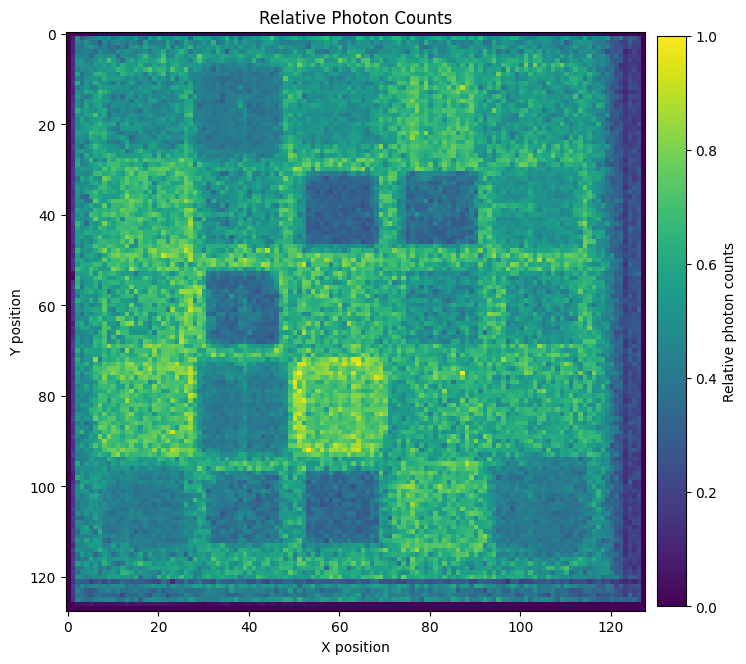

In [28]:
plot_pad_max_peak_positions(DataPreprocessor._normalize(e_xy), object_name)
plot_pad_photon_counts(DataPreprocessor._normalize(e_xy), object_name)

4720.75
232.59493670886076


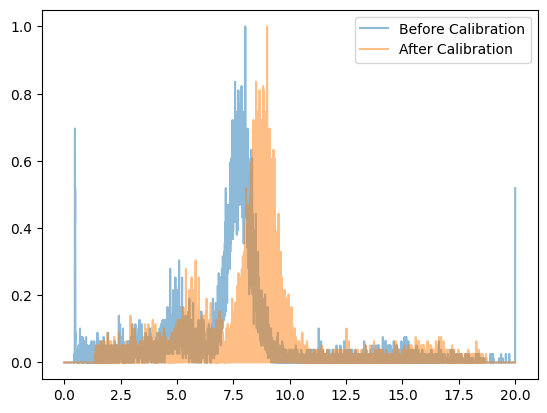

In [29]:
plt.plot(np.linspace(0, 20, 4096), DataPreprocessor._normalize(aa), label="Before Calibration", alpha=0.5)
plt.plot(np.linspace(0, 20, 4096), DataPreprocessor._normalize(e_xy[20, 40]), label="After Calibration", alpha=0.5)
plt.legend()
print(np.sum(aa))
print(np.sum(e_xy[20, 40]))

In [30]:
result = {"e_xy": DataPreprocessor._normalize(e_xy), "peaks": peaks, "peak_energies": peak_energies }
np.savez(
    f"data/objects/processed/{object_name}_{patch_size}x{patch_size}_patches_discrete.npz", **result
)